In [1]:
# ================================================================
# Part A - Standard Computer Vision Workflow
# Dataset folder: project_data
# Structure:
# project_data/
#   train/
#   valid/
#   test/
# ================================================================

import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense
from keras.optimizers import Adam

In [2]:
# ================================================================
# Task 1: Data Preparation
# ================================================================

print("----- Task 1: Data Preparation -----")

TRAIN_PATH = "./project_data/train"
VALID_PATH = "./project_data/valid"
TEST_PATH = "./project_data/test"

IMG_SIZE = (64, 64)


def load_images(directory, image_size=(64, 64)):
    X_values = []
    y_values = []
    class_names = []

    folders = sorted([
        f for f in os.listdir(directory)
        if not f.startswith(".") and os.path.isdir(os.path.join(directory, f))
    ])

    class_names = folders

    for label, each_folder in enumerate(folders):
        sub_path = os.path.join(directory, each_folder)

        for each_image in sorted(os.listdir(sub_path)):
            if not each_image.startswith("."):
                full_path = os.path.join(sub_path, each_image)

                image = cv2.imread(full_path)

                if image is not None:
                    image = cv2.resize(image, image_size)
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

                    X_values.append(image)
                    y_values.append(label)

    return X_values, y_values, class_names


X_train_list, y_train_list, class_names = load_images(TRAIN_PATH, IMG_SIZE)
X_val_list, y_val_list, _ = load_images(VALID_PATH, IMG_SIZE)
X_test_list, y_test_list, _ = load_images(TEST_PATH, IMG_SIZE)

print("Number of classes:", len(class_names))
print("Class names:", class_names[:5], "...")

----- Task 1: Data Preparation -----
Number of classes: 53
Class names: ['ace of clubs', 'ace of diamonds', 'ace of hearts', 'ace of spades', 'eight of clubs'] ...


In [3]:
# ================================================================
# Task 2: Convert to NumPy Arrays
# ================================================================

print("\n----- Task 2: Convert to NumPy Arrays -----")

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

X_val = np.array(X_val_list)
y_val = np.array(y_val_list)

X_test = np.array(X_test_list)
y_test = np.array(y_test_list)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


----- Task 2: Convert to NumPy Arrays -----
X_train shape: (7624, 64, 64)
y_train shape: (7624,)
X_val shape: (265, 64, 64)
y_val shape: (265,)
X_test shape: (265, 64, 64)
y_test shape: (265,)



----- Task 3: Visualization -----


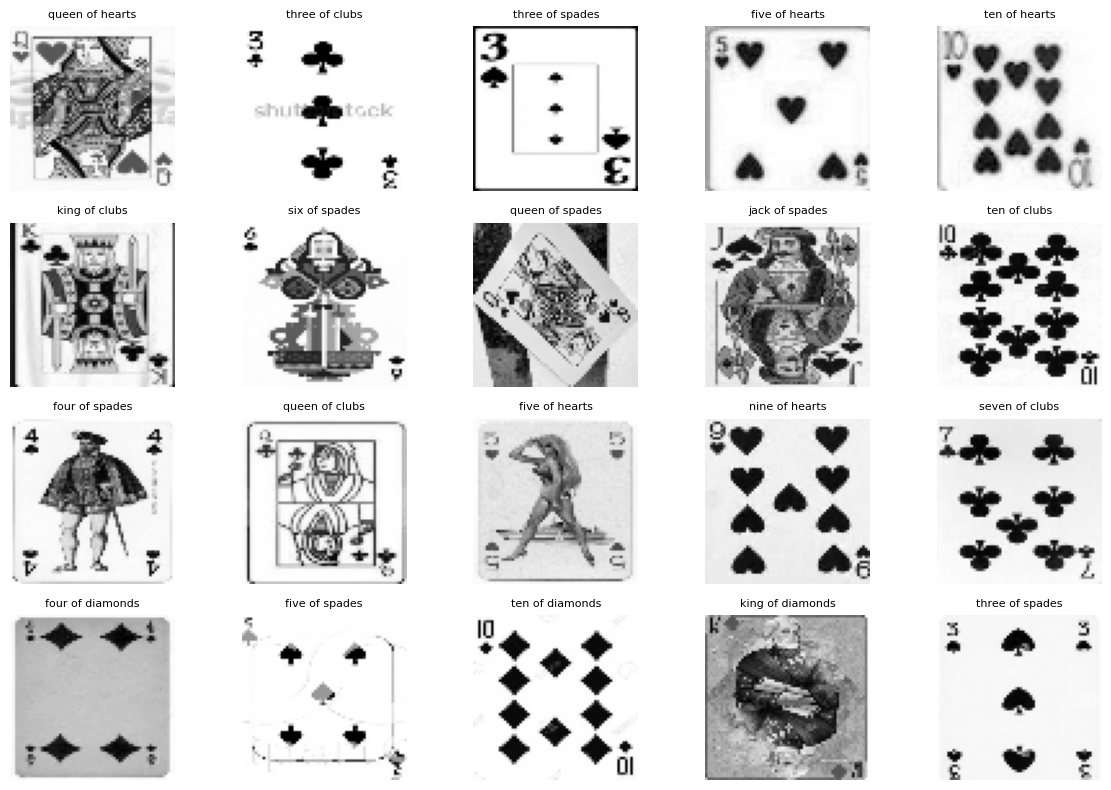

In [4]:
# ================================================================
# Task 3: Visualization - 20 Random Samples
# ================================================================

print("\n----- Task 3: Visualization -----")

plt.figure(figsize=(12, 8))

for i in range(20):
    index = random.randint(0, len(X_train) - 1)

    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[index], cmap="gray")
    plt.title(class_names[y_train[index]], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# ================================================================
# Task 4: Normalization and Reshape to 4D Tensor
# ================================================================

print("\n----- Task 4: Normalization and Reshape -----")

X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 64, 64, 1)
X_val = X_val.reshape(-1, 64, 64, 1)
X_test = X_test.reshape(-1, 64, 64, 1)

print("After reshape:")
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


----- Task 4: Normalization and Reshape -----
After reshape:
X_train shape: (7624, 64, 64, 1)
X_val shape: (265, 64, 64, 1)
X_test shape: (265, 64, 64, 1)


In [6]:
# ================================================================
# Task 5: CNN Modeling
# Standard Lab 05b style: Conv2D -> Flatten -> Dense
# ================================================================

print("\n----- Task 5: CNN Modeling -----")

num_classes = len(class_names)

cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=1,
        padding="same",
        activation="relu",
        input_shape=(64, 64, 1)
    )
)

cnn_model.add(Flatten())

cnn_model.add(
    Dense(
        num_classes,
        activation="softmax"
    )
)

cnn_model.summary()


----- Task 5: CNN Modeling -----

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        320       
                                                                 
 flatten (Flatten)           (None, 131072)            0         
                                                                 
 dense (Dense)               (None, 53)                6946869   
                                                                 
Total params: 6947189 (26.50 MB)
Trainable params: 6947189 (26.50 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
# ================================================================
# Task 6: Compile and Train
# ================================================================

print("\n----- Task 6: Training -----")

cnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

history = cnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32)


----- Task 6: Training -----
Epoch 1/10


239/239 [==============================] - 11s 44ms/step - loss: 3.9426 - accuracy: 0.2423 - val_loss: 2.0099 - val_accuracy: 0.5057
Epoch 2/10
239/239 [==============================] - 10s 44ms/step - loss: 1.1710 - accuracy: 0.7252 - val_loss: 1.6486 - val_accuracy: 0.5811
Epoch 3/10
239/239 [==============================] - 10s 44ms/step - loss: 0.4280 - accuracy: 0.9187 - val_loss: 1.6487 - val_accuracy: 0.6151
Epoch 4/10
239/239 [==============================] - 11s 44ms/step - loss: 0.1882 - accuracy: 0.9732 - val_loss: 1.8033 - val_accuracy: 0.6377
Epoch 5/10
239/239 [==============================] - 11s 44ms/step - loss: 0.1108 - accuracy: 0.9854 - val_loss: 1.9387 - val_accuracy: 0.5925
Epoch 6/10
239/239 [==============================] - 11s 44ms/step - loss: 0.0751 - accuracy: 0.9928 - val_loss: 1.8718 - val_accuracy: 0.6151
Epoch 7/10
239/239 [==============================] - 11s 44ms/step - loss: 0.0560 - accuracy: 0.9933 - 


----- Task 7: Loss Curve -----


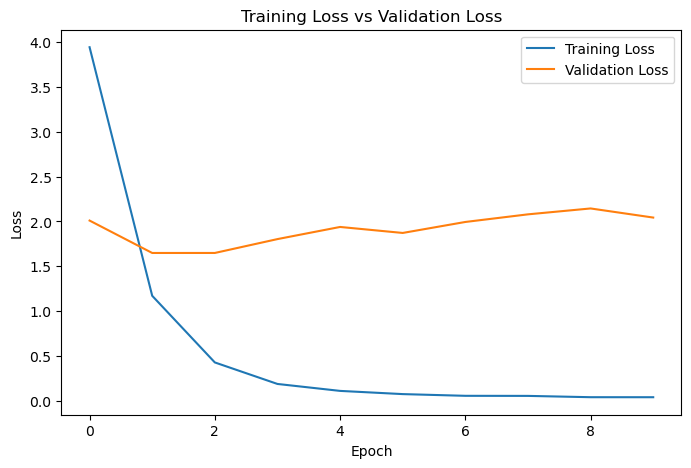

In [8]:
# ================================================================
# Task 7: Plot Loss Curves
# ================================================================

print("\n----- Task 7: Loss Curve -----")

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


----- Task 8: Accuracy Curve -----


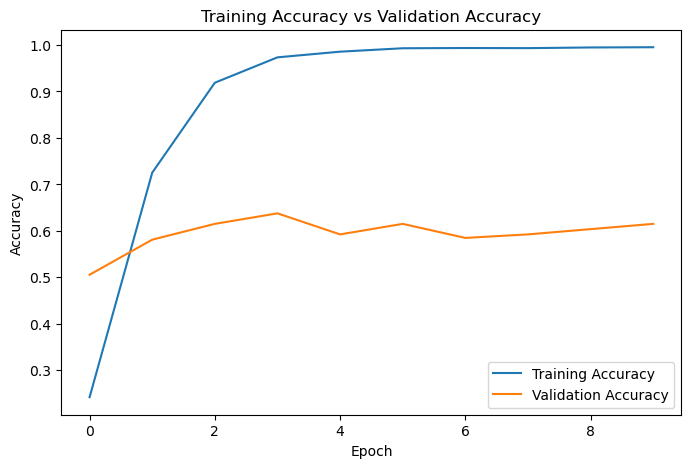

In [9]:
# ================================================================
# Task 8: Plot Accuracy Curves
# ================================================================

print("\n----- Task 8: Accuracy Curve -----")

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [10]:
# ================================================================
# Task 9: Evaluate on Separate Test Set
# Do not use test set during training
# ================================================================

print("\n----- Task 9: Test Set Evaluation -----")

test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


----- Task 9: Test Set Evaluation -----
9/9 [==============================] - 0s 7ms/step - loss: 2.0695 - accuracy: 0.6038
Test Loss: 2.069542646408081
Test Accuracy: 0.6037735939025879


In [11]:
# ================================================================
# Task 10: Prediction and Classification Report
# ================================================================

print("\n----- Task 10: Classification Report -----")

y_pred = cnn_model.predict(X_test).argmax(axis=1)

print("Converted Labels:", y_pred[:10])

print(
    classification_report(
        y_true=y_test,
        y_pred=y_pred,
        target_names=class_names,
        zero_division=0
    )
)


----- Task 10: Classification Report -----
9/9 [==============================] - 0s 6ms/step
Converted Labels: [29  0  0  0  0  1  3  1  1  1]
                   precision    recall  f1-score   support

     ace of clubs       0.80      0.80      0.80         5
  ace of diamonds       0.80      0.80      0.80         5
    ace of hearts       0.67      0.80      0.73         5
    ace of spades       0.50      0.80      0.62         5
   eight of clubs       0.62      1.00      0.77         5
eight of diamonds       0.50      0.80      0.62         5
  eight of hearts       0.60      0.60      0.60         5
  eight of spades       0.50      0.20      0.29         5
    five of clubs       0.33      0.60      0.43         5
 five of diamonds       0.43      0.60      0.50         5
   five of hearts       1.00      0.60      0.75         5
   five of spades       0.67      0.40      0.50         5
    four of clubs       0.40      0.40      0.40         5
 four of diamonds       1.00